# Example: Let's Build a Regression Model of Housing Prices with Regularization and SVD
How does a ridge penalty change the parameters of a linear model, and what does the singular value decomposition tell us about that change? We'll use a housing price dataset to connect the ridge regression formulas from [the lecture](CHEME-5800-L8c-Lecture-RegularizationAndGeneralization-Fall-2026.ipynb) to a numerical calculation.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * **Estimate a baseline model with ordinary least squares:** The ordinary least squares estimate is the parameter vector that minimizes the sum of squared differences between the observed and predicted house prices. We'll estimate it from a training set and measure the prediction error on the training set and on a held-out testing set.
> * **Estimate the model parameters with ridge regression:** Ridge regression adds a penalty on the size of the parameters to the least-squares problem, and a regularization parameter sets the strength of that penalty. We'll compute the ridge estimate, compare each parameter with its unregularized value, and see how the training and testing errors change.
> * **Compute the ridge estimate with the singular value decomposition:** The singular value decomposition writes the ridge estimate as a weighted sum of the right singular vectors of the training data matrix, where a filter factor shrinks each term. We'll compute the filter factors, find the term that the penalty shrinks the most, and check that the sum agrees with the direct calculation.

In this example, we estimate a linear model of house prices with and without a ridge penalty, and use the singular value decomposition of the training data to see where the penalty acts. Let's get started!
___

## Setup, Data, and Prerequisites
First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project, defines local paths, and loads the packages used here.

Let's set up our code environment:

In [1]:
# Load packages and data paths -
include(joinpath(@__DIR__, "Include.jl")) # @__DIR__ locates this notebook's setup file

# Choose the plot appearance -
# After changing the theme, rerun this cell and the plotting cells.
theme(:default)   # light background
# theme(:dark)   # dark background

See the [Julia documentation](https://docs.julialang.org/en/v1/), the [LinearAlgebra.jl documentation](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/), and the [DataFrames.jl documentation](https://dataframes.juliadata.org/stable/) for the functions and types used here.

### Data
We will develop a model to estimate housing prices based on factors like house area, bedrooms, furnished status, nearness to the main road, etc. The dataset is small: it holds the price and twelve features for 545 houses.

> __Acknowledgement__
>
> The housing dataset is adapted from [Kaggle](https://www.kaggle.com/datasets/yasserh/housing-prices-dataset?select=Housing.csv), whose acknowledgement lists the following references:
>
> * Harrison, D. and Rubinfeld, D.L. (1978) Hedonic prices and the demand for clean air. J. Environ. Economics and Management 5, 81–102.
> * Belsley D.A., Kuh, E. and Welsch, R.E. (1980) Regression Diagnostics. Identifying Influential Data and Sources of Collinearity. New York: Wiley.

The dataset is stored in [the `Housing-Training-Dataset-Kaggle.csv` file](data/Housing-Training-Dataset-Kaggle.csv) in this example's `data` folder. We read it with [the `CSV.read(...)` function](https://csv.juliadata.org/stable/reading.html#CSV.read), which returns the housing dataset [as a `DataFrame` instance](https://dataframes.juliadata.org/stable/).

Let's save the raw (unwrangled) data in the `original_dataset::DataFrame` variable:

In [2]:
original_dataset = CSV.read(joinpath(_PATH_TO_DATA, "Housing-Training-Dataset-Kaggle.csv"), DataFrame) # load the *original* dataset

Row,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
,Int64,Int64,Int64,Int64,Int64,String3,String3,String3,String3,String3,Int64,String3,String15
1,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
2,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
3,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
4,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
5,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
6,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
7,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
8,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
9,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished


Notice that we have several columns (features) that are categorical, i.e., `{furnished | semi-furnished | unfurnished}` or `{yes | no}`. We must replace these values with numbers: we encode `{yes | no}` as `{1 | -1}` and the furnishing status as `{1 | 0 | -1}`. For this example, we interpret the listed prices as USD. We rescale the price to millions of USD and the area to thousands of square feet, so that the columns have comparable magnitudes.

> __Transformation:__ We'll transform the categorical features (including changing types from a `String` to an `Int`) using [the `transform!(...)` method exported by the DataFrames.jl package](https://dataframes.juliadata.org/stable/lib/functions/#DataFrames.transform!). This is an advanced operation, so if this is unclear, please review the [DataFrames.jl documentation](https://dataframes.juliadata.org/stable/lib/functions/#DataFrames.transform!) for more information.

We'll save the transformed dataset in the `treated_dataset::DataFrame` variable:

In [3]:
treated_dataset = let

    # initialize -
    treated_dataset = copy(original_dataset); # work on a copy, so the original data stays unchanged

    # encode the {yes | no} features as {1 | -1} -
    transform!(treated_dataset, :mainroad => ByRow( x-> (x=="yes" ? 1 : -1)) => :t_mainroad);
    transform!(treated_dataset, :guestroom => ByRow( x-> (x=="yes" ? 1 : -1)) => :t_guestroom);
    transform!(treated_dataset, :basement => ByRow( x-> (x=="yes" ? 1 : -1)) => :t_basement);
    transform!(treated_dataset, :hotwaterheating => ByRow( x-> (x=="yes" ? 1 : -1)) => :t_hotwaterheating);
    transform!(treated_dataset, :airconditioning => ByRow( x-> (x=="yes" ? 1 : -1)) => :t_airconditioning);
    transform!(treated_dataset, :prefarea => ByRow( x-> (x=="yes" ? 1 : -1)) => :t_prefarea);

    # encode the furnishing status as {1 | 0 | -1} -
    transform!(treated_dataset, :furnishingstatus => ByRow( x-> (x=="unfurnished" ? -1 : (x=="semi-furnished" ? 0 : 1))) => :t_furnishingstatus);

    # rescale the price and the area -
    transform!(treated_dataset, :price => ByRow(x -> x/1000000.0) => :t_price); # price in 1M USD
    transform!(treated_dataset, :area => ByRow(x -> x/1000.0) => :t_area); # area in thousands of square feet

    # remove the original columns -
    select!(treated_dataset, Not([:mainroad,:guestroom,:basement,:hotwaterheating,:airconditioning,:prefarea,:furnishingstatus,:price, :area]))
end

Row,bedrooms,bathrooms,stories,parking,t_mainroad,t_guestroom,t_basement,t_hotwaterheating,t_airconditioning,t_prefarea,t_furnishingstatus,t_price,t_area
,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Float64,Float64
1,4,2,3,2,1,-1,-1,-1,1,1,1,13.3,7.42
2,4,4,4,3,1,-1,-1,-1,1,-1,1,12.25,8.96
3,3,2,2,2,1,-1,1,-1,-1,1,0,12.25,9.96
4,4,2,2,3,1,-1,1,-1,1,1,1,12.215,7.5
5,4,1,2,2,1,1,1,-1,1,-1,1,11.41,7.42
6,3,3,1,2,1,-1,1,-1,1,1,0,10.85,7.5
7,4,3,4,2,1,-1,-1,-1,1,1,0,10.15,8.58
8,5,3,2,0,1,-1,-1,-1,-1,-1,-1,10.15,16.2
9,4,1,2,2,1,1,1,-1,1,1,1,9.87,8.1


Now let's split the dataset into the system input matrix $\mathbf{X}$ (independent variables, characteristics of the house) and the output vector $\mathbf{y}$ (dependent variable, the house price).

The input matrix $\mathbf{X}$ will contain all the columns except for the `t_price` column (the output variable). The output vector $\mathbf{y}$ will contain only the `t_price` column. We also save the names of the columns of $\mathbf{X}$, followed by an `intercept` label, in the `feature_labels::Vector{String}` variable, so that we can label the model parameters in the tables that follow:

In [4]:
X = Matrix(treated_dataset[:, Not(:t_price)]); # data matrix: select all the columns *except* price
y = Vector(treated_dataset[:, :t_price]); # output vector: select the price column
feature_labels = [names(treated_dataset, Not(:t_price))..., "intercept"]; # one label per model parameter

Finally, let's partition the data into a `training` and `testing` set so that we can determine how well the model can predict unseen data, i.e., how well the model generalizes.

We select the training houses at random with a seeded random number generator, so the split is the same every time we run the notebook. We also append a column of ones to each data matrix, which gives the augmented data matrix $\hat{\mathbf{X}}$ whose last column multiplies the intercept. Each set is a `NamedTuple` with the fields `X` (the augmented data matrix) and `y` (the prices):

In [5]:
training, testing = let

    # initialize -
    s = 0.80; # fraction of data for training
    seed = 1234; # seed for the random number generator; change it to get a different split
    rng = MersenneTwister(seed); # random number generator used only for this split
    number_of_samples = size(X,1); # number of houses in the dataset
    number_of_training_samples = floor(Int, s*number_of_samples); # 80% of the data for training
    i = randperm(rng, number_of_samples); # random permutation of the row indices
    training_indices = i[1:number_of_training_samples]; # first 80% of the shuffled indices
    testing_indices = i[number_of_training_samples+1:end]; # last 20% of the shuffled indices

    # setup training -
    one_vector = ones(number_of_training_samples); # column of ones for the intercept
    training = (X=[X[training_indices, :] one_vector], y=y[training_indices]);

    # setup testing -
    one_vector = ones(length(testing_indices)); # column of ones for the intercept
    testing = (X=[X[testing_indices, :] one_vector], y=y[testing_indices]);

    training, testing; # return
end;

___

## Task 1: Estimate the model parameters without regularization
In this task, we estimate the parameters of the housing price model with ordinary least squares (OLS), and compute the prediction error on the training and testing sets. We will compare the regularized models in Tasks 2 and 3 with this model.

The training data matrix $\hat{\mathbf{X}}\in\mathbb{R}^{n\times{p}}$ is overdetermined, i.e., $n>p$ (more observations than parameters): with the default split, we have $n = 436$ training houses and $p = 13$ parameters (twelve features and the intercept). Thus, we are solving the minimization problem for the unknown parameter estimates $\hat{\mathbf{\theta}}$:

$$
\begin{equation*}
\hat{\mathbf{\theta}} = \arg\min_{\mathbf{\theta}} \frac{1}{2}\;\lVert~\mathbf{y} - \hat{\mathbf{X}}\;\mathbf{\theta}~\rVert^{2}_{2}
\end{equation*}
$$

where $\lVert\star\rVert^{2}_{2}$ is the square of the L2 vector norm. Then, the value of the unknown parameter vector $\mathbf{\theta}$ that minimizes the sum of squares loss function for an overdetermined system with full column rank is given by:

$$
\begin{align*}
\hat{\mathbf{\theta}} &= \left(\hat{\mathbf{X}}^{\top}\hat{\mathbf{X}}\right)^{-1}\hat{\mathbf{X}}^{\top}\mathbf{y}
\end{align*}
$$

This is the OLS estimate that we derived in the L7c lecture. Let's compute an estimate of the model parameters $\hat{\mathbf{\theta}}$ using the training dataset. We'll save it in the `θ̂₁::Vector{Float64}` variable:

In [6]:
θ̂₁ = let

    # initialize -
    X = training.X; # augmented training data matrix
    y = training.y; # training prices

    # compute the OLS estimate -
    θ = inv(transpose(X)*X)*transpose(X)*y; # normal equations

    θ; # return
end;

Now that we have the model parameters, let's evaluate the model performance on the `training` and `testing` datasets.

We can compute the predicted output vector $\hat{\mathbf{y}} = \hat{\mathbf{X}}\hat{\mathbf{\theta}}$ using the learned model parameters $\hat{\mathbf{\theta}}$ and the data matrix $\hat{\mathbf{X}}$ from each dataset.

We'll save the model output for the `training` dataset in the `predicted_training_y::Vector{Float64}` variable and the model output for the `testing` dataset in the `predicted_testing_y::Vector{Float64}` variable:

In [7]:
predicted_training_y = training.X * θ̂₁; # predicted output for the training data
predicted_testing_y = testing.X * θ̂₁; # predicted output for the testing data

### Analysis: Training and Testing Error
Let's compute the error for the training case. We measure the error with the root-mean-square error (RMSE) between the observed prices $\mathbf{y}$ and the predicted prices $\hat{\mathbf{y}}$:

$$
\begin{equation*}
\text{RMSE} = \frac{1}{\sqrt{N}}\;\lVert~\mathbf{y} - \hat{\mathbf{y}}~\rVert_{2}
\end{equation*}
$$

where $N$ is the number of houses in the dataset. The RMSE has the units of the price (1M USD), so we can read it as the size of a typical prediction error for one house.

> __Error:__ We use [the `norm(...)` function exported by the `LinearAlgebra.jl` package](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.norm) to compute the distance (error) between the observed output and the calculated output values. We store this in the `ϵ_train` variable. The larger the `ϵ_train`, the __worse__ the model is learning the data. Thus, a large value of `ϵ_train` is bad.

So, what is the value of `ϵ_train::Float64`?

In [8]:
ϵ_train = let

    # initialize -
    N = length(predicted_training_y); # number of training houses
    y = training.y; # observed training prices

    # compute the training error -
    r = y .- predicted_training_y; # residual: observed price minus model price
    ϵ_train = norm(r)/sqrt(N); # root-mean-square error, 1M USD

    ϵ_train; # return
end

1.0820447283516987

We can do the same analysis for the `testing` dataset. We'll save the error metric in the `ϵ_test::Float64` variable:

In [9]:
ϵ_test = let

    # initialize -
    N = length(predicted_testing_y); # number of testing houses
    y = testing.y; # observed testing prices

    # compute the testing error -
    r = y .- predicted_testing_y; # residual: observed price minus model price
    ϵ_test = norm(r)/sqrt(N); # root-mean-square error, 1M USD

    ϵ_test; # return
end

0.9629475362678457

__What do we see?__ Both errors are close to one million USD, for houses that sell for between 1.75 and 13.3 million USD. The testing error is close to the training error (for this split it is a little smaller), so the model predicts houses it has not seen about as well as the houses we used to estimate its parameters. With 436 training houses and only 13 parameters, the unregularized model has little room to overfit. Your values will change if you change the seed or the training fraction.

Next, let's plot the model price against the observed price for the _training data_ and the _test data_. A model that reproduced every price would put all the points on the equality line:

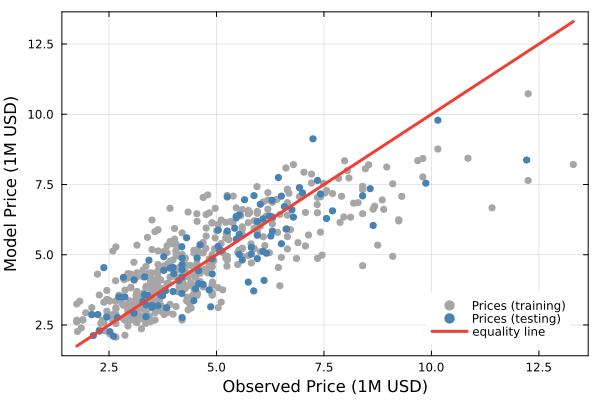

In [10]:
let

    # initialize -
    y_train = training.y; # observed training prices
    ŷ_train = predicted_training_y; # model training prices
    y_test = testing.y; # observed testing prices
    ŷ_test = predicted_testing_y; # model testing prices

    # equality line: spans the smallest and largest price on either axis -
    lower = minimum([y_train; ŷ_train; y_test; ŷ_test]);
    upper = maximum([y_train; ŷ_train; y_test; ŷ_test]);
    xy_line = [lower, upper]; # two points define the line

    # plot -
    scatter(y_train, ŷ_train, label="Prices (training)", c=:gray65, msc=:gray65)
    scatter!(y_test, ŷ_test, label="Prices (testing)", c=:steelblue, msc=:steelblue)
    plot!(xy_line, xy_line, lw=3, label="equality line", c=colorant"#EF4035");

    xlabel!("Observed Price (1M USD)")
    ylabel!("Model Price (1M USD)")
    plot!(framestyle = :box, fg_legend = :transparent, legend = :bottomright);
end

The points scatter around the equality line, and the training and testing points overlap. The model underestimates the price of the most expensive houses, which fall below the line.

___

## Task 2: Estimate the model parameters with ridge regression
In this task, we estimate the housing model parameters with ridge regression, and compare the parameters and the prediction errors with the unregularized model from Task 1.

There are several types of regularization techniques, but we will focus on __Ridge regression__ (also known as Tikhonov regularization or L2 regularization). The ridge regression problem is given by:

$$
\begin{align*}
\hat{\mathbf{\theta}}_{\delta} = \arg\min_{\mathbf{\theta}}\left( \frac{1}{2}\;\lVert~\mathbf{y} - \hat{\mathbf{X}}\;\mathbf{\theta}~\rVert^{2}_{2} + \frac{\delta}{2}\;\lVert~\mathbf{\theta}~\rVert^{2}_{2}\right)
\end{align*}
$$

where $\delta\geq 0$ is the regularization parameter controlling regularization strength. The first term measures the sum of squared errors, while the second term penalizes large parameter values. The analytical solution for the optimal parameters is given by:

$$
\begin{align*}
\hat{\mathbf{\theta}}_{\delta} &= \left(\hat{\mathbf{X}}^{\top}\hat{\mathbf{X}} + \delta\;\mathbf{I}\right)^{-1}\hat{\mathbf{X}}^{\top}\mathbf{y}
\end{align*}
$$

The penalty applies to every entry of $\mathbf{\theta}$, including the intercept, which is the last entry.

Let's start by setting the regularization parameter `δ::Float64`:

In [11]:
δ = 1.0; # regularization parameter; δ = 0 gives the OLS estimate

Next, let's compute the model parameters directly using the ridge regression formula. We'll save the model parameters in the `θ̂₂::Vector{Float64}` variable:

In [12]:
θ̂₂ = let

    # initialize -
    X = training.X; # augmented training data matrix
    y = training.y; # training prices
    p = size(X,2); # number of parameters

    # compute the ridge regression parameters -
    θ_ridge = inv(transpose(X)*X + δ*I(p))*transpose(X)*y; # I(p) is the p × p identity matrix

    θ_ridge; # return
end;

What are the values of the model parameters `θ̂₂::Vector{Float64}` compared to the model parameters `θ̂₁::Vector{Float64}` computed without regularization in Task 1? Let's build a table with one row per parameter, where the `Δ` column is the relative change $(\hat{\theta}_{\delta,j} - \hat{\theta}_{j})/|\hat{\theta}_{j}|$ of parameter $j$:

In [13]:
let

    # initialize -
    df = DataFrame(); # hold the data (rows) for the table

    # build the rows of the table -
    for i ∈ eachindex(θ̂₂)

        center_1 = θ̂₁[i]; # OLS estimate of parameter i
        center_2 = θ̂₂[i]; # ridge estimate of parameter i

        row_df = (
            i = i,
            feature = feature_labels[i],
            ols = round(center_1, digits=4),
            ridge = round(center_2, digits=4),
            Δ  = ((center_2 - center_1)/abs(center_1)) |> x-> round(x, digits=4) # relative change
        ) # data for the row

        push!(df, row_df) # add the row to the dataframe
    end

    # show the table -
    pretty_table(df;
        show_first_column_label_only = true,
        display_size = (-1, -1), # show every row and column
        alignment = [:r, :l, :r, :r, :r] # left-align text and right-align numerical columns
    );
end

┌────┬────────────────────┬────────┬────────┬─────────┐
│  i │ feature            │    ols │  ridge │       Δ │
├────┼────────────────────┼────────┼────────┼─────────┤
│  1 │ bedrooms           │ 0.0926 │ 0.1113 │  0.2021 │
│  2 │ bathrooms          │  1.061 │   1.06 │ -0.0009 │
│  3 │ stories            │ 0.4238 │ 0.4272 │  0.0082 │
│  4 │ parking            │ 0.2738 │ 0.2738 │  0.0002 │
│  5 │ t_mainroad         │ 0.1922 │ 0.1974 │  0.0274 │
│  6 │ t_guestroom        │ 0.1771 │ 0.1727 │ -0.0245 │
│  7 │ t_basement         │ 0.1451 │ 0.1451 │ -0.0003 │
│  8 │ t_hotwaterheating  │ 0.4643 │ 0.4372 │ -0.0582 │
│  9 │ t_airconditioning  │ 0.3965 │ 0.3881 │ -0.0213 │
│ 10 │ t_prefarea         │ 0.3505 │ 0.3428 │ -0.0221 │
│ 11 │ t_furnishingstatus │ 0.2096 │ 0.2087 │ -0.0044 │
│ 12 │ t_area             │ 0.2599 │ 0.2636 │  0.0141 │
│ 13 │ intercept          │ 1.6088 │ 1.4881 │  -0.075 │
└────┴────────────────────┴────────┴────────┴─────────┘


__What do we see?__ Most of the ridge parameters are within a few percent of their OLS values. For this split and $\delta = 1$, the largest changes are in the intercept, which decreases by about 7.5%, and in the bedrooms parameter, which increases by about 20%. The penalty acts on the length of the parameter vector as a whole, so one parameter can grow while another shrinks. These values change with the split and with `δ`.

Now let's compute the training error for the regularized model. We'll use the same approach as in Task 1, computing the root-mean-square error between the observed and predicted housing prices.

What is the value of `ϵ_training_regularization::Float64`?

In [14]:
ϵ_training_regularization = let

    # initialize -
    predicted_training_y = training.X * θ̂₂; # predicted output for the training data
    N = length(predicted_training_y); # number of training houses
    y = training.y; # observed training prices

    # compute the training error -
    r = y .- predicted_training_y; # residual: observed price minus model price
    ϵ_training = norm(r)/sqrt(N); # root-mean-square error, 1M USD

    ϵ_training; # return
end

1.082250055441149

We can do the same analysis for the `testing` dataset with the regularized model. We'll save the error metric in the `ϵ_test_regularization::Float64` variable:

In [15]:
ϵ_test_regularization = let

    # initialize -
    predicted_testing_y = testing.X * θ̂₂; # predicted output for the testing data
    N = length(predicted_testing_y); # number of testing houses
    y = testing.y; # observed testing prices

    # compute the testing error -
    r = y .- predicted_testing_y; # residual: observed price minus model price
    ϵ_test = norm(r)/sqrt(N); # root-mean-square error, 1M USD

    ϵ_test; # return
end

0.9623930597182089

Let's put the errors of the two models side by side, along with the length $\lVert\hat{\mathbf{\theta}}\rVert_{2}$ of each parameter vector:

In [16]:
let

    # put the errors and the parameter norms into a DataFrame -
    df = DataFrame(
        model = ["OLS (δ = 0)", "ridge (δ = $(δ))"], # one row per model
        training_error = round.([ϵ_train, ϵ_training_regularization], digits=4), # RMSE, 1M USD
        testing_error = round.([ϵ_test, ϵ_test_regularization], digits=4), # RMSE, 1M USD
        parameter_norm = round.([norm(θ̂₁), norm(θ̂₂)], digits=4) # length of the parameter vector
    );

    # show the table -
    pretty_table(df;
        show_first_column_label_only = true,
        display_size = (-1, -1), # show every row and column
        alignment = [:l, :r, :r, :r] # left-align text and right-align numerical columns
    );
end

┌─────────────────┬────────────────┬───────────────┬────────────────┐
│ model           │ training_error │ testing_error │ parameter_norm │
├─────────────────┼────────────────┼───────────────┼────────────────┤
│ OLS (δ = 0)     │          1.082 │        0.9629 │         2.1619 │
│ ridge (δ = 1.0) │         1.0823 │        0.9624 │         2.0665 │
└─────────────────┴────────────────┴───────────────┴────────────────┘


__What do we see?__ The training error of the ridge model is slightly larger than the OLS training error. This has to happen: the OLS estimate minimizes the training error, so every other parameter vector does at least as badly on the training data. In exchange, the ridge parameter vector is about 4% shorter. The testing error changes by less than 0.1% for this split and $\delta = 1$, so this small penalty has almost no effect on how well the model predicts unseen houses. Try `δ = 10.0` or `δ = 100.0` and rerun the cells in this task to see the training error grow as the penalty becomes stronger.

Finally, let's plot the model price against the observed price for the unregularized model ($\delta = 0$, open markers) and the ridge model (filled markers), for both the _training data_ and _test data_:

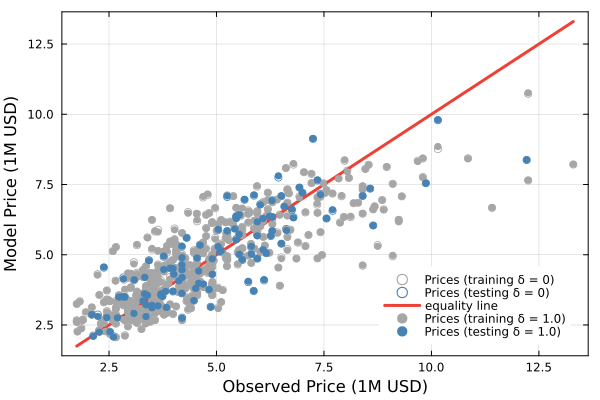

In [17]:
let

    # unregularized model -
    y_train = training.y; # observed training prices
    ŷ_train = training.X * θ̂₁; # OLS training prices
    y_test = testing.y; # observed testing prices
    ŷ_test = testing.X * θ̂₁; # OLS testing prices

    # ridge model -
    ŷ_train_ridge = training.X * θ̂₂; # ridge training prices
    ŷ_test_ridge = testing.X * θ̂₂; # ridge testing prices

    # equality line: spans the smallest and largest price on either axis -
    lower = minimum([y_train; ŷ_train; y_test; ŷ_test]);
    upper = maximum([y_train; ŷ_train; y_test; ŷ_test]);
    xy_line = [lower, upper]; # two points define the line

    # plot the unregularized model with open markers -
    canvas = default(:bg); # background color of the current plot theme, used to fill the open markers
    scatter(y_train, ŷ_train, label="Prices (training δ = 0)", c=canvas, msc=:gray65)
    scatter!(y_test, ŷ_test, label="Prices (testing δ = 0)", c=canvas, msc=:steelblue)
    plot!(xy_line, xy_line, lw=3, label="equality line", c=colorant"#EF4035");

    # plot the ridge model with filled markers -
    scatter!(y_train, ŷ_train_ridge, label="Prices (training δ = $(δ))", c=:gray65, msc=:gray65)
    scatter!(y_test, ŷ_test_ridge, label="Prices (testing δ = $(δ))", c=:steelblue, msc=:steelblue)

    xlabel!("Observed Price (1M USD)")
    ylabel!("Model Price (1M USD)")
    plot!(framestyle = :box, fg_legend = :transparent, legend = :bottomright);
end

The filled markers sit almost exactly on the open markers: the two models make nearly the same predictions, even though some of their parameters differ by several percent. The singular value decomposition of the training data matrix shows why.

___

## Task 3: Compute the ridge estimate with the SVD
In this task, we compute the ridge estimate from the singular value decomposition (SVD) of the training data matrix, and look at how much the penalty shrinks each term of the sum. Computing the estimate with the SVD is often more numerically stable than using the normal equations directly, especially when the data matrix is ill-conditioned or nearly singular.

Let the SVD of the training data matrix be $\hat{\mathbf{X}} = \mathbf{U}\;\mathbf{S}\;\mathbf{V}^{\top}$. The regularized least-squares estimate (ridge regression) of the unknown parameter vector $\mathbf{\theta}$ is given by (in index notation):

$$
\begin{align*}
\hat{\mathbf{\theta}}_{\delta} = \sum_{i=1}^{r(\hat{\mathbf{X}})}\left(\frac{\sigma_{i}}{\sigma_{i}^{2}+\delta}\right)\left(\mathbf{u}_{i}^{\top}\mathbf{y}\right)\mathbf{v}_{i}
= \sum_{i=1}^{r(\hat{\mathbf{X}})}\underbrace{\left(\frac{\sigma_{i}^{2}}{\sigma_{i}^{2}+\delta}\right)}_{\text{filter factor}}\left(\frac{\mathbf{u}_{i}^{\top}\mathbf{y}}{\sigma_{i}}\right)\mathbf{v}_{i}
\end{align*}
$$

where $r(\hat{\mathbf{X}})$ is the rank of the data matrix $\hat{\mathbf{X}}$, $\mathbf{u}_{i}$ and $\mathbf{v}_{i}$ are the $i$-th columns of $\mathbf{U}$ and $\mathbf{V}$, respectively, $\sigma_{i}>0$ is the $i$-th singular value, and $\delta \geq 0$ is the regularization parameter.

The second form is the OLS sum from the L7c lecture, where term $i$ has the weight $1/\sigma_{i}$, with each term multiplied by a __filter factor__ $\sigma_{i}^{2}/(\sigma_{i}^{2}+\delta)$. The filter factor is close to one when $\sigma_{i}^{2}\gg\delta$ and close to zero when $\sigma_{i}^{2}\ll\delta$, so the penalty shrinks the terms with the smallest singular values the most.

Let's compute the SVD of the training data matrix with [the `svd(...)` function exported by the `LinearAlgebra.jl` package](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.svd). We save the left singular vectors in the columns of `U::Matrix{Float64}`, the singular values (largest first) in `S::Vector{Float64}`, and the right singular vectors in the columns of `V::Matrix{Float64}`:

In [18]:
U, S, V = svd(training.X); # thin SVD: U is n × p, S holds the p singular values, V is p × p

### Shrinkage of each term
How much does the penalty shrink each term of the sum? Let's list the singular values with the OLS weight $1/\sigma_{i}$, the ridge weight $\sigma_{i}/(\sigma_{i}^{2}+\delta)$, and the filter factor for each term. We also print the condition number of the training data matrix, which is the ratio of its largest to its smallest singular value (the [condition number notebook](CHEME-5800-L8c-Theory-ConditionNumber-Fall-2026.ipynb) explains what it measures):

In [19]:
let

    # initialize -
    df = DataFrame(); # hold the data (rows) for the table
    κ = S[1]/S[end]; # condition number: largest singular value over the smallest

    # build the rows of the table -
    for i ∈ eachindex(S)

        σᵢ = S[i]; # i-th singular value

        row_df = (
            i = i,
            σ = round(σᵢ, digits=4),
            ols_weight = round(1/σᵢ, digits=4), # weight of term i in the OLS sum
            ridge_weight = round(σᵢ/(σᵢ^2 + δ), digits=4), # weight of term i in the ridge sum
            filter_factor = round(σᵢ^2/(σᵢ^2 + δ), digits=4) # ridge weight divided by OLS weight
        ) # data for the row

        push!(df, row_df) # add the row to the dataframe
    end

    # show the table and the condition number -
    pretty_table(df;
        show_first_column_label_only = true,
        display_size = (-1, -1), # show every row and column
        alignment = [:r, :r, :r, :r, :r] # right-align numerical columns
    );
    println("Condition number of the training data matrix: $(round(κ, digits=2))");
end

┌────┬─────────┬────────────┬──────────────┬───────────────┐
│  i │       σ │ ols_weight │ ridge_weight │ filter_factor │
├────┼─────────┼────────────┼──────────────┼───────────────┤
│  1 │ 142.691 │      0.007 │        0.007 │           1.0 │
│  2 │ 30.0723 │     0.0333 │       0.0332 │        0.9989 │
│  3 │ 22.8736 │     0.0437 │       0.0436 │        0.9981 │
│  4 │ 20.6244 │     0.0485 │       0.0484 │        0.9977 │
│  5 │ 16.8059 │     0.0595 │       0.0593 │        0.9965 │
│  6 │ 16.5514 │     0.0604 │       0.0602 │        0.9964 │
│  7 │ 14.8748 │     0.0672 │       0.0669 │        0.9955 │
│  8 │ 13.9131 │     0.0719 │       0.0715 │        0.9949 │
│  9 │ 13.4903 │     0.0741 │       0.0737 │        0.9945 │
│ 10 │ 11.5423 │     0.0866 │        0.086 │        0.9925 │
│ 11 │  9.6962 │     0.1031 │        0.102 │        0.9895 │
│ 12 │  8.7928 │     0.1137 │       0.1123 │        0.9872 │
│ 13 │  3.3845 │     0.2955 │       0.2717 │        0.9197 │
└────┴─────────┴────────

__What do we see?__ With $\delta = 1$, the filter factors of the first twelve terms are above 0.98, so the penalty leaves those terms almost unchanged. The last term has the smallest singular value and the largest OLS weight, and the penalty shrinks it by about 8%. The condition number is about 42 for this split, so the training data matrix is well conditioned.

__Why did the predictions barely change in Task 2?__ Almost all of the difference between the ridge and the OLS parameters lies along the last right singular vector, which points mostly along the intercept for this split. The data matrix scales a change of the parameters along $\mathbf{v}_{i}$ by $\sigma_{i}$, so a change along the direction with the smallest singular value changes the predicted prices the least.

### SVD parameter estimation
Now, let's compute the model parameters using the SVD sum. We'll save them in the `θ̂₃::Vector{Float64}` variable. We use all $r(\hat{\mathbf{X}})$ terms, which we get from [the `rank(...)` function exported by the `LinearAlgebra.jl` package](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.rank), so the sum gives the same estimate as the direct ridge regression formula.

__Note:__ The commented line `r = 1` is an alternative that keeps only the term with the largest singular value. This performs aggressive dimensionality reduction by projecting the estimate onto the single direction $\mathbf{v}_{1}$, which is a different model from ridge regression with all the terms. With `r = 1`, the first test in the check at the end of this task fails.

In [20]:
θ̂₃ = let

    # initialize -
    r = rank(training.X); # number of terms in the sum: full rank
    # r = 1; # alternative: keep only the term with the largest singular value
    θ = zeros(size(V,1)); # parameter estimate, built up one term at a time

    # estimate the parameters -
    for i ∈ 1:r
        σᵢ = S[i]; # i-th singular value
        uᵢ = U[:,i]; # i-th left singular vector
        vᵢ = V[:,i]; # i-th right singular vector
        a = σᵢ/(σᵢ^2 + δ); # ridge weight of term i
        b = dot(uᵢ, training.y); # projection of the training prices onto uᵢ
        θ .+= a*b*vᵢ; # add term i to the estimate
    end

    θ; # return
end;

What are the values of the model parameters `θ̂₃::Vector{Float64}` compared to the model parameters computed using the direct ridge regression formula (`θ̂₂`) and without regularization (`θ̂₁`)?

In [21]:
let

    # initialize -
    df = DataFrame(); # hold the data (rows) for the table

    # build the rows of the table -
    for i ∈ eachindex(θ̂₃)

        row_df = (
            i = i,
            feature = feature_labels[i],
            ols = round(θ̂₁[i], digits=4), # OLS estimate, Task 1
            ridge = round(θ̂₂[i], digits=4), # direct ridge estimate, Task 2
            ridge_svd = round(θ̂₃[i], digits=4), # ridge estimate from the SVD sum
        ) # data for the row

        push!(df, row_df) # add the row to the dataframe
    end

    # show the table -
    pretty_table(df;
        show_first_column_label_only = true,
        display_size = (-1, -1), # show every row and column
        alignment = [:r, :l, :r, :r, :r] # left-align text and right-align numerical columns
    );
end

┌────┬────────────────────┬────────┬────────┬───────────┐
│  i │ feature            │    ols │  ridge │ ridge_svd │
├────┼────────────────────┼────────┼────────┼───────────┤
│  1 │ bedrooms           │ 0.0926 │ 0.1113 │    0.1113 │
│  2 │ bathrooms          │  1.061 │   1.06 │      1.06 │
│  3 │ stories            │ 0.4238 │ 0.4272 │    0.4272 │
│  4 │ parking            │ 0.2738 │ 0.2738 │    0.2738 │
│  5 │ t_mainroad         │ 0.1922 │ 0.1974 │    0.1974 │
│  6 │ t_guestroom        │ 0.1771 │ 0.1727 │    0.1727 │
│  7 │ t_basement         │ 0.1451 │ 0.1451 │    0.1451 │
│  8 │ t_hotwaterheating  │ 0.4643 │ 0.4372 │    0.4372 │
│  9 │ t_airconditioning  │ 0.3965 │ 0.3881 │    0.3881 │
│ 10 │ t_prefarea         │ 0.3505 │ 0.3428 │    0.3428 │
│ 11 │ t_furnishingstatus │ 0.2096 │ 0.2087 │    0.2087 │
│ 12 │ t_area             │ 0.2599 │ 0.2636 │    0.2636 │
│ 13 │ intercept          │ 1.6088 │ 1.4881 │    1.4881 │
└────┴────────────────────┴────────┴────────┴───────────┘


With all the terms in the sum, the `ridge_svd` column matches the `ridge` column in every displayed digit. Let's confirm this, and the other relationships that we used in this example, with a few tests.

### Check: Ridge estimates
Let's check that the SVD sum reproduces the direct ridge estimate, and that the SVD sum with $\delta = 0$ recovers the OLS estimate. We also check that the ridge training error is at least as large as the OLS training error, and that the ridge parameter vector is no longer than the OLS parameter vector. We allow a small numerical tolerance when comparing floating-point results.

In [22]:
let

    # initialize -
    tolerance = 1e-8; # absolute tolerance for comparing parameter estimates
    y = training.y; # training prices

    # SVD sum with δ = 0: term i has the OLS weight 1/σᵢ -
    θ_ols_svd = sum((dot(U[:,i], y)/S[i])*V[:,i] for i ∈ eachindex(S)); # sum over a generator, one term per singular value

    # check the estimates -
    @testset "Ridge regression estimate checks" begin
        @test isapprox(θ̂₃, θ̂₂; atol=tolerance) # the SVD sum agrees with the direct ridge formula
        @test isapprox(θ_ols_svd, θ̂₁; atol=tolerance) # δ = 0 recovers the OLS estimate
        @test ϵ_training_regularization >= ϵ_train # the OLS estimate minimizes the training error
        @test norm(θ̂₂) <= norm(θ̂₁) # the penalty shortens the parameter vector
    end
end;

Test Summary:                    | Pass  Total  Time
Ridge regression estimate checks |    4      4  0.4s


___

## Summary
In this example, we estimated a linear model of housing prices with ordinary least squares and with ridge regression, and used the singular value decomposition to see where the ridge penalty acts.

> __Key Takeaways:__
>
> * **Ordinary least squares sets the baseline:** We estimated the model parameters from the training houses with the normal equations and measured the root-mean-square error on the training and testing sets. We found that the two errors were close, which is what we expect when there are many more houses than parameters.
> * **The ridge penalty shortens the parameter vector:** We added a penalty on the size of the parameters to the least-squares problem and compared each ridge parameter with its unregularized value. We saw the training error increase slightly and the parameter vector get shorter, while the testing error barely changed for the small penalty we chose.
> * **The SVD shows where the penalty acts:** We wrote the ridge estimate as a sum over the singular values of the training data matrix, with a filter factor that shrinks each term. We found that the penalty shrank the term with the smallest singular value the most, and that the sum reproduced the direct ridge estimate.

We can now change the regularization parameter, the seed of the split, or the number of terms in the SVD sum and see how the parameters and the prediction errors respond.

___